# Geometry Of Data HW 5 Submission

#### und5uv Sravanth Chowdary Potluri


In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

We are going to make a 2D pdf as a mixture of two Gaussians, one of which we will apply a nonlinear spatial transform to make it more interesting. 

These are functions for a Gaussian pdf in $\mathbb{R}^2$ and its gradient.

In [2]:
def gauss(x, mu, omega):
    return (0.5 * omega / np.pi) * torch.exp(-0.5 * omega * torch.sum((x - mu)**2, axis = 1))

def grad_gauss(x, mu, omega):
    g = gauss(x, mu, omega)
    return (-0.5 * omega**2 / np.pi) * (g.reshape((g.shape[0], 1)).repeat(1, 2) * (x - mu))

Here is a nonlinearity $\phi : \mathbb{R}^2 \rightarrow \mathbb{R}^2$ that we'll apply to one of the Gaussians.

In [3]:
def phi(x):
    return torch.column_stack((x[:, 0], x[:, 1] + 0.25 * np.sin(4.0 * np.pi * x[:, 0])))

def dphi(x):
    return torch.column_stack((x[:, 0] + np.pi * np.cos(4.0 * np.pi * x[:, 0]) * x[:, 1], x[:, 1]))

Our final pdf will be

$$f(x) = \frac{1}{C} \exp(-U(x)),$$

where $C$ is a normalizing constant, and $U(x)$ is the energy:

$$U(x) = \ln\left(\lambda_1 \mathcal{N}\left(x; \mu_1, \omega_1^{-1} I\right) + \lambda_2 \mathcal{N}\left(\phi(x); \mu_2, \omega_2^{-1} I\right) \right),$$

where $\lambda_1, \lambda_2$ are mixture weights, $\mu_1, \mu_2 \in \mathbb{R}^2$ are the means, and $\omega_1, \omega_2 > 0$ are the precisions of Gaussian components.

In [4]:
# Parameters for the pdf
mu1 = torch.Tensor([1.0, 1.0])
mu2 = torch.Tensor([-1.0, -1.0])
omega1 = 9.0
omega2 = 9.0
lambda1 = 0.4
lambda2 = 0.6

# For taking logs near zero
epsilon = 1.0e-8

def U(x):
    e1 = lambda1 * gauss(x, mu1, omega1)
    e2 = lambda2 * gauss(phi(x), mu2, omega2)

    return -np.log(e1 + e2 + epsilon)

Here is the gradient of the energy (a.k.a., negative log pdf). You'll need this for either the Langevin or Hamiltonian Monte Carlo methods

In [5]:
def grad_U(x):
    e1 = lambda1 * gauss(x, mu1, omega1)
    e2 = lambda2 * gauss(phi(x), mu2, omega2)
    
    grad_e1 = lambda1 * grad_gauss(x, mu1, omega1)
    grad_e2 = lambda2 * dphi(grad_gauss(phi(x), mu2, omega2))

    a = (-1.0 / (e1 + e2 + epsilon)).reshape((e1.shape[0], 1))
    return a.repeat(1, 2) * (grad_e1 + grad_e2)

/var/folders/_r/qvq82mn570z3cjtf48bv_fgc0000gn/T/ipykernel_20577/2938977958.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return torch.column_stack((x[:, 0], x[:, 1] + 0.25 * np.sin(4.0 * np.pi * x[:, 0])))
/var/folders/_r/qvq82mn570z3cjtf48bv_fgc0000gn/T/ipykernel_20577/2411601948.py:16: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return -np.log(e1 + e2 + epsilon)
/var/folders/_r/qvq82mn570z3cjtf48bv_fgc0000gn/T/ipykernel_20577/484235659.py:10: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  dens = np.exp(-U(coords))


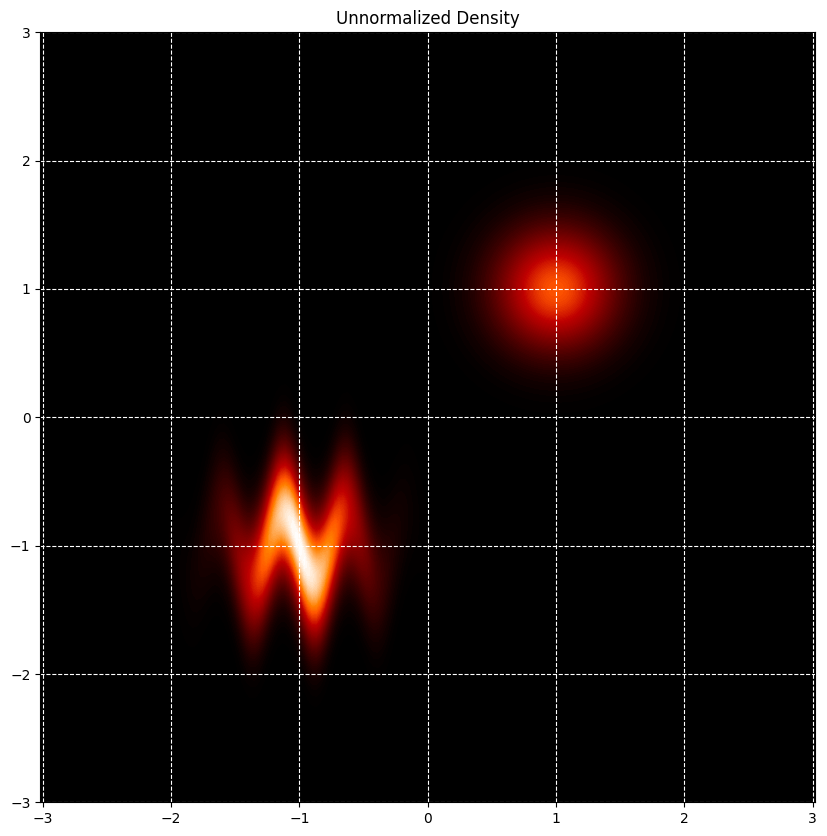

In [9]:
# Make grid for plotting
xcoord = np.linspace(-3.0, 3.0, 201)
ycoord = np.linspace(-3.0, 3.0, 201)
xx, yy = np.meshgrid(xcoord, ycoord)

# reshape xx,yy coordinates into N x 2 tensor
coords = torch.Tensor(np.column_stack((xx.flatten(), yy.flatten())))

# compute (unnormalized) density function
dens = np.exp(-U(coords))

# reshape back to the xx,yy grid
dens = dens.reshape(xx.shape).numpy()

# Contour plot
levels = np.linspace(np.max(dens) / 100, np.max(dens), 99)
plt.figure(figsize = (10, 10))
ax = plt.axes()
ax.set_facecolor("black")
plt.contourf(xx, yy, dens, levels = levels, cmap = "gist_heat")

plt.title("Unnormalized Density")
plt.grid(color='white', linestyle = '--')

plt.axis('equal')
plt.show()

Repeating the density plot with an overlay of the $-\nabla U$ field.

/var/folders/_r/qvq82mn570z3cjtf48bv_fgc0000gn/T/ipykernel_20577/2938977958.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return torch.column_stack((x[:, 0], x[:, 1] + 0.25 * np.sin(4.0 * np.pi * x[:, 0])))
/var/folders/_r/qvq82mn570z3cjtf48bv_fgc0000gn/T/ipykernel_20577/2411601948.py:16: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return -np.log(e1 + e2 + epsilon)
/var/folders/_r/qvq82mn570z3cjtf48bv_fgc0000gn/T/ipykernel_20577/225151305.py:22: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  dens = np.exp(-U(coords))
/var/folders/_r/qvq82mn570z3cjtf48bv_fgc0000gn/T/ipykernel_20577/2938977958.py:5: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future.

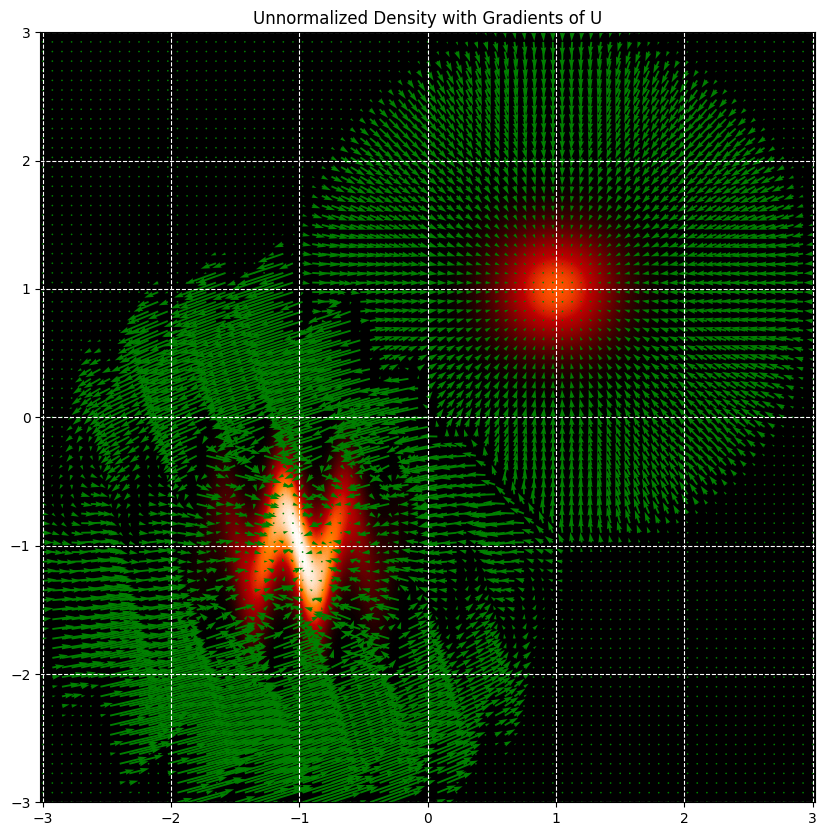

In [7]:
# Contour plot
levels = np.linspace(np.max(dens) / 100, np.max(dens), 99)
plt.figure(figsize = (10, 10))
ax = plt.axes()
ax.set_facecolor("black")
plt.contourf(xx, yy, dens, levels = levels, cmap = "gist_heat")

plt.title("Unnormalized Density with Gradients of U")
plt.grid(color='white', linestyle = '--')

plt.axis('equal')

## Gradient field plot ############################################
xcoord = np.linspace(-3.0, 3.0, 81)
ycoord = np.linspace(-3.0, 3.0, 81)
gxx, gyy = np.meshgrid(xcoord, ycoord)

# reshape xx,yy coordinates into N x 2 tensor
coords = torch.Tensor(np.column_stack((gxx.flatten(), gyy.flatten())))

# compute (unnormalized) density function
dens = np.exp(-U(coords))
grads = -grad_U(coords)

# reshape back to the xx,yy grid
grads_u = grads[:,0].reshape(gxx.shape).numpy()
grads_v = grads[:,1].reshape(gxx.shape).numpy()

plt.quiver(gxx, gyy, grads_u, grads_v, color='g', scale = 1000)
#####################################################################

plt.show()

/var/folders/_r/qvq82mn570z3cjtf48bv_fgc0000gn/T/ipykernel_20577/2938977958.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return torch.column_stack((x[:, 0], x[:, 1] + 0.25 * np.sin(4.0 * np.pi * x[:, 0])))
/var/folders/_r/qvq82mn570z3cjtf48bv_fgc0000gn/T/ipykernel_20577/2411601948.py:16: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return -np.log(e1 + e2 + epsilon)


Number of accepted samples: 6660
Independence Sampler: sigma^2=0.001, acceptance_rate=0.666


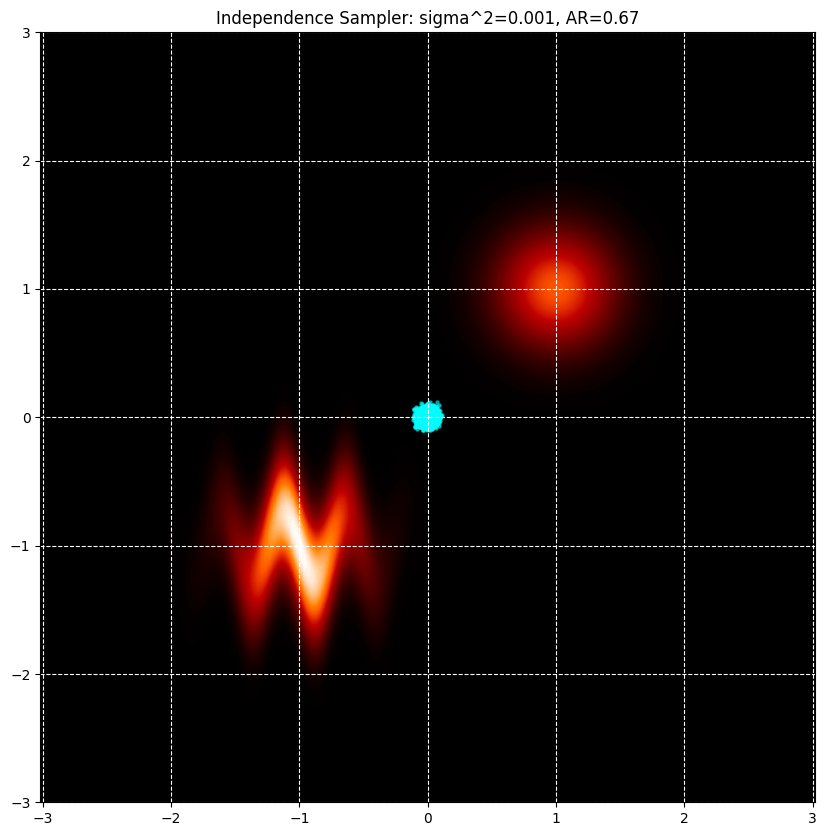

Number of accepted samples: 1520
Independence Sampler: sigma^2=1.0, acceptance_rate=0.152


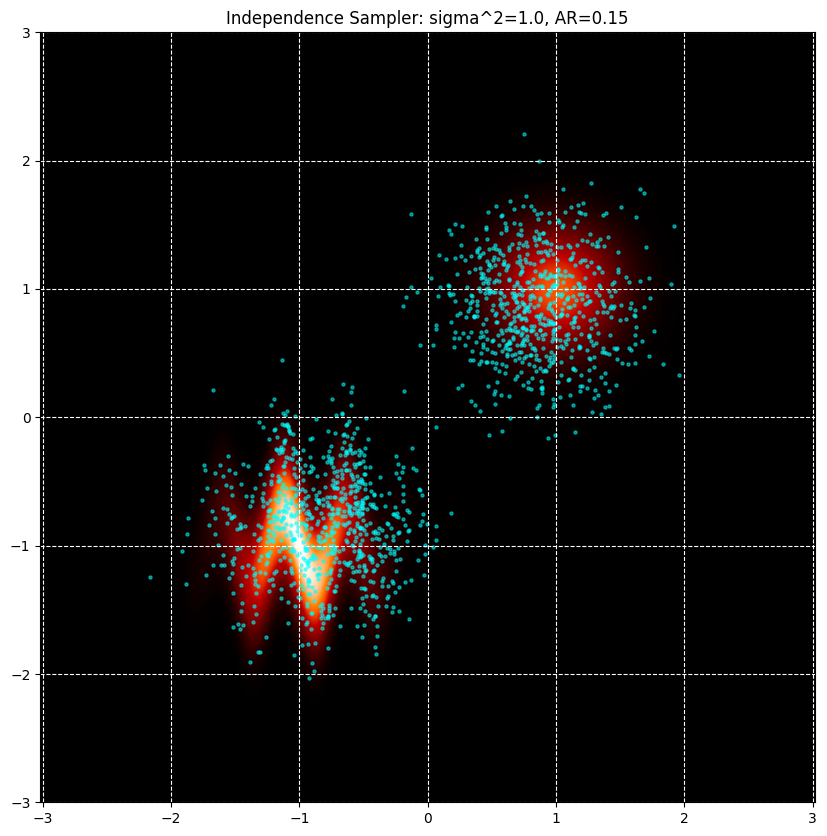

Number of accepted samples: 702
Independence Sampler: sigma^2=5.0, acceptance_rate=0.070


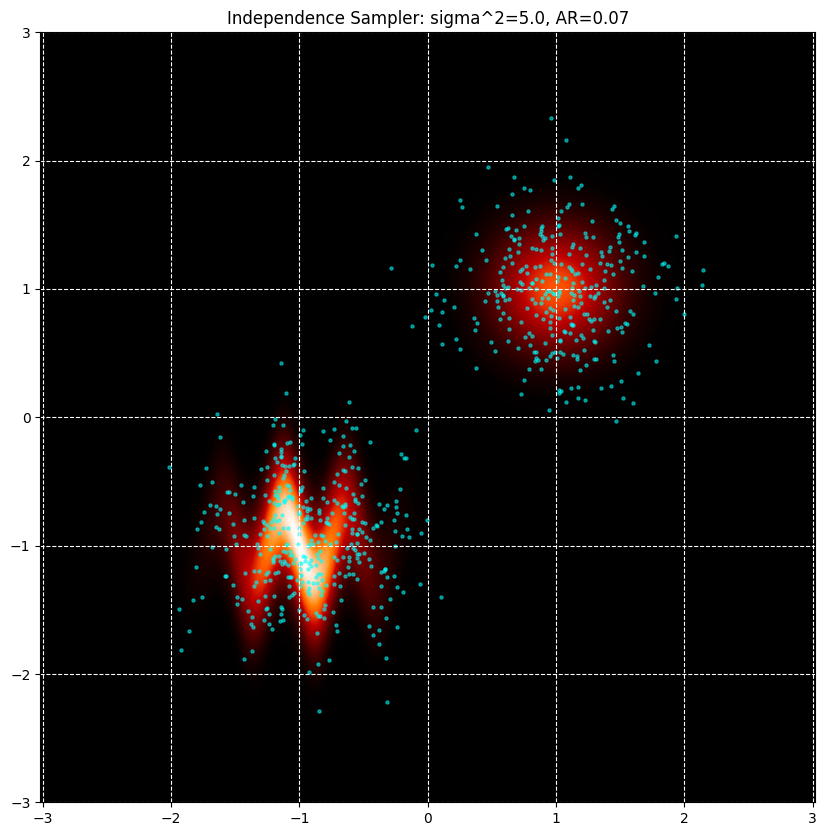

Number of accepted samples: 402
Independence Sampler: sigma^2=10.0, acceptance_rate=0.040


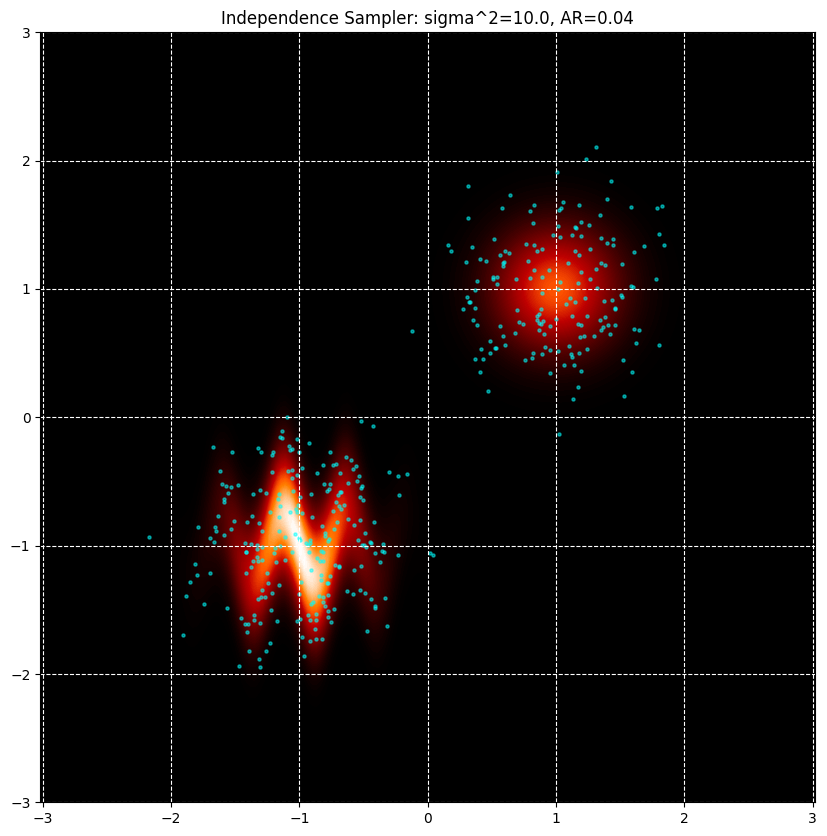

Number of accepted samples: 6
Independence Sampler: sigma^2=1000, acceptance_rate=0.001


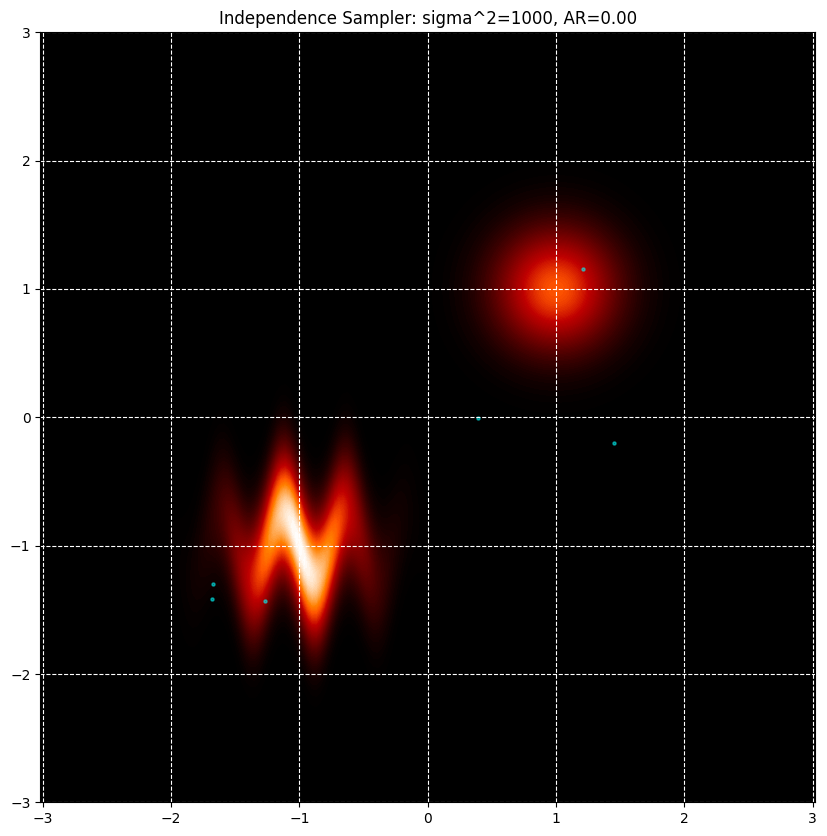

In [11]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# We have U and grad_U defined from the starter code.
# Also, dens, xx, yy grids are available from the starter code.

###############################################
# 1) Independence Sampler
###############################################

def independence_sampler(U, n_samples=10000, sigma_sq=1.0, seed=42):
    torch.manual_seed(seed)
    samples = []
    accept_count = 0

    # Start from some initial point, say (0,0)
    x_current = torch.zeros(1,2)
    f_current = torch.exp(-U(x_current))[0].item()

    for i in range(n_samples):
        # Propose from N(0, sigma_sq I)
        y = sigma_sq**0.5 * torch.randn(1,2)
        f_proposed = torch.exp(-U(y))[0].item()

        # numerator and denominator g are symmetric therefore they are the same and have no effect on the acce
        alpha = min(1, f_proposed / f_current)

        # Accept/Reject
        if np.random.rand() <= alpha:
            x_current = y
            f_current = f_proposed
            accept_count += 1
            samples.append(x_current.numpy().flatten())

    print("Number of accepted samples:", accept_count)
    samples = np.array(samples)
    acceptance_rate = accept_count / n_samples
    return samples, acceptance_rate

# Run the independence sampler with three different sigma^2 values
for sigma_sq in [0.001, 1.0, 5.0, 10.0,1000]:
    samples, ar = independence_sampler(U, n_samples=10000, sigma_sq=sigma_sq)
    print(f"Independence Sampler: sigma^2={sigma_sq}, acceptance_rate={ar:.3f}")

    # Plot accepted samples over the density
    plt.figure(figsize=(10,10))
    ax = plt.axes()
    ax.set_facecolor("black")
    plt.contourf(xx, yy, dens, levels = levels, cmap = "gist_heat")
    plt.scatter(samples[:,0], samples[:,1], c='cyan', s=5, alpha=0.5)
    plt.title(f"Independence Sampler: sigma^2={sigma_sq}, AR={ar:.2f}")
    plt.grid(color='white', linestyle = '--')
    plt.axis('equal')
    plt.show()


#### At smaller values of $\sigma^2$ the independence sampler samples the points very very close to the initial seed point at 0,0 and mean of the proposal is also 0. However in this scenario of distribution, the points surrounding 0,0 are acceptable samples for the distribution leading to a relatively high accept rate of 0.67 at 0.001 $\sigma^2$. That being said as the value of $\sigma^2$ increases the acceptance rates fall because the proposal samples are sparse and a lot of the samples will be further away from the actual distribution and land in lower density regions and cannot be accepted

/var/folders/_r/qvq82mn570z3cjtf48bv_fgc0000gn/T/ipykernel_20577/2938977958.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return torch.column_stack((x[:, 0], x[:, 1] + 0.25 * np.sin(4.0 * np.pi * x[:, 0])))
/var/folders/_r/qvq82mn570z3cjtf48bv_fgc0000gn/T/ipykernel_20577/2411601948.py:16: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return -np.log(e1 + e2 + epsilon)


Number of accepted samples: 9542
RWM: sigma^2=0.001, acceptance_rate=0.954


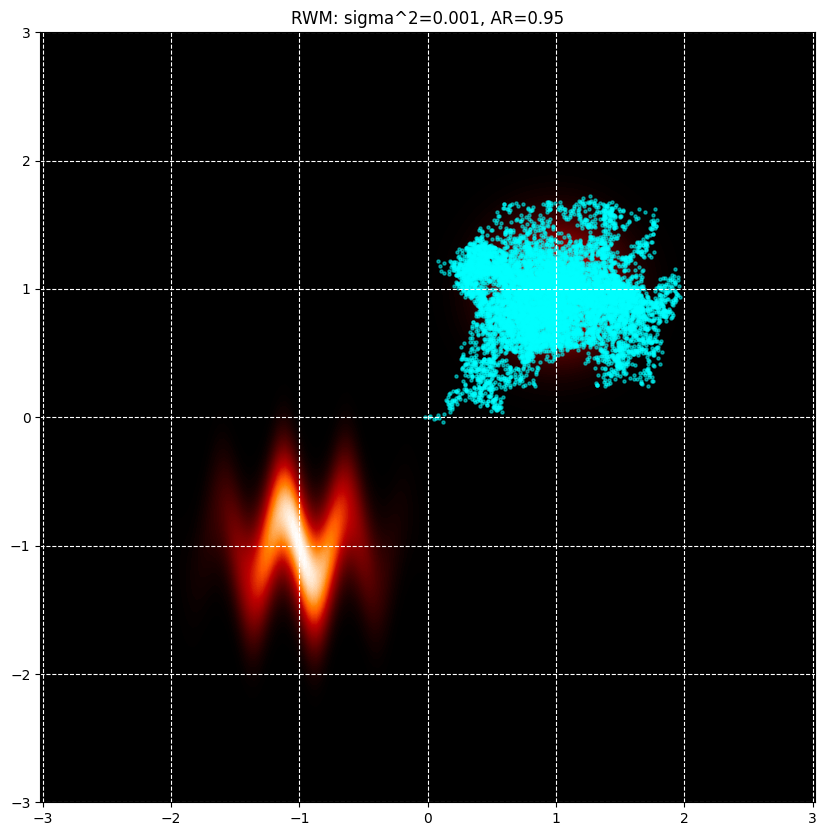

Number of accepted samples: 1791
RWM: sigma^2=1.0, acceptance_rate=0.179


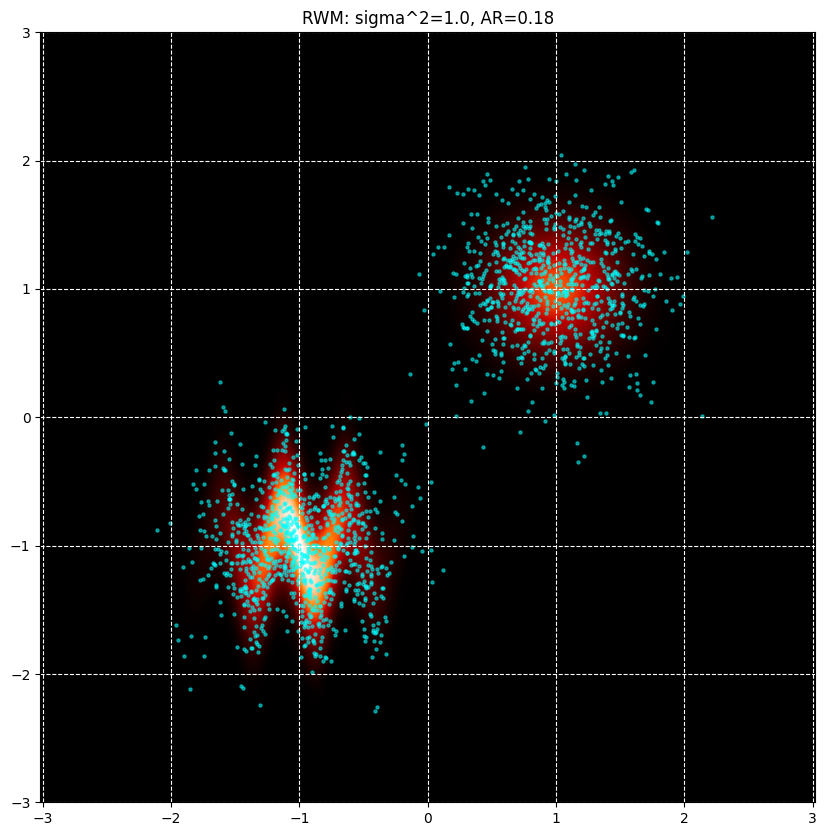

Number of accepted samples: 615
RWM: sigma^2=5.0, acceptance_rate=0.061


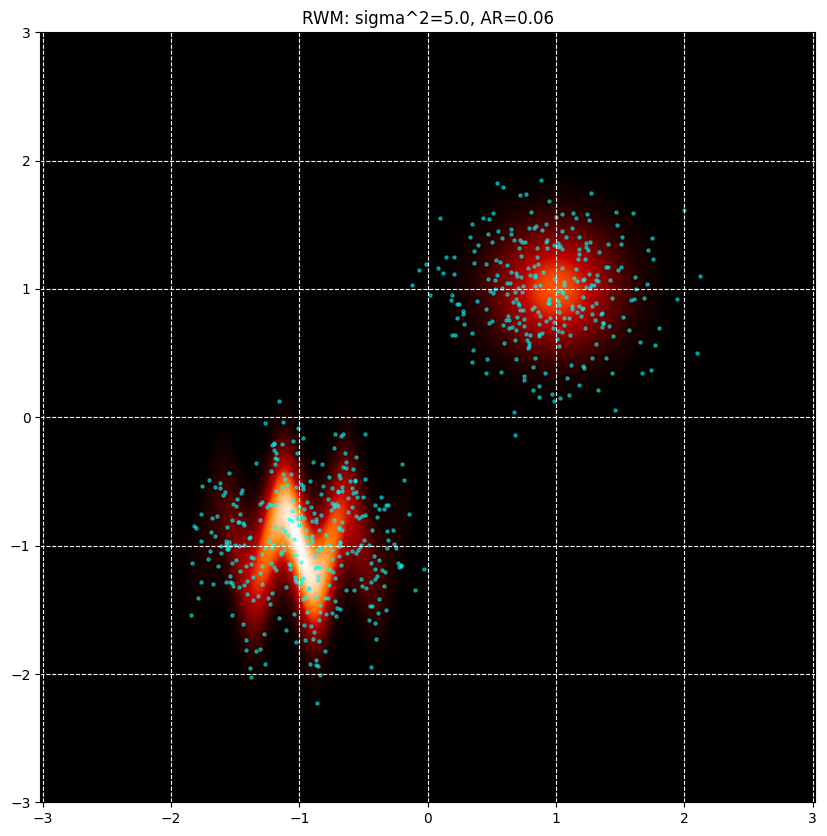

Number of accepted samples: 329
RWM: sigma^2=10.0, acceptance_rate=0.033


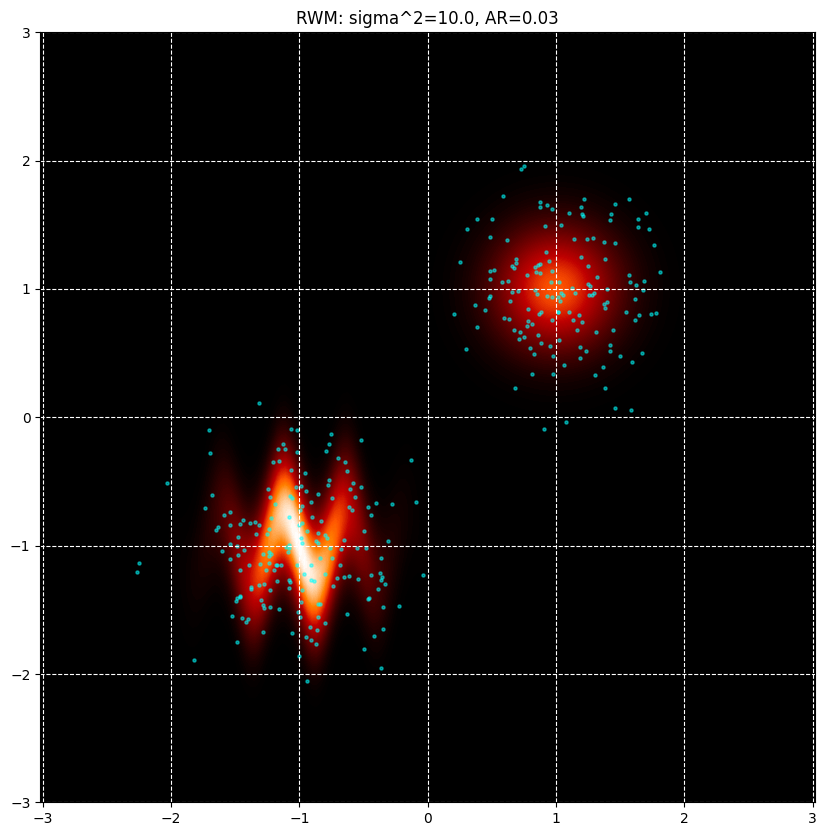

Number of accepted samples: 10
RWM: sigma^2=1000, acceptance_rate=0.001


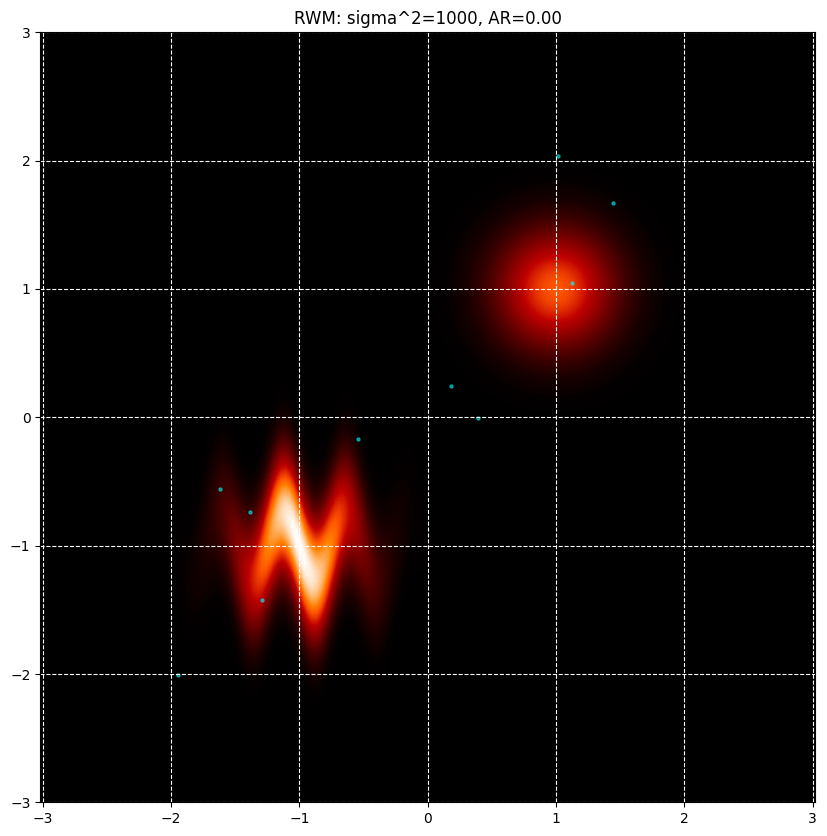

In [12]:
###############################################
# 2) Random Walk Metropolis Sampler
###############################################

def random_walk_metropolis(U, n_samples=10000, sigma_sq=1.0, seed=42):
    torch.manual_seed(seed)
    samples = []
    accept_count = 0

    x_current = torch.zeros(1,2)
    f_current = torch.exp(-U(x_current))[0].item()

    for i in range(n_samples):
        # Propose from N(x_current, sigma_sq I)
        y = x_current + sigma_sq**0.5 * torch.randn(1,2)
        f_proposed = torch.exp(-U(y))[0].item()

        # since the proposal distribution is symmetric, i.e it's a distance and g(y|x) = g(x|y) the terms in numerator and denominator get cancelled, the alpha i.e acceptance probability becomes.
        alpha = min(1, f_proposed / f_current)

        if np.random.rand() <= alpha:
            x_current = y
            f_current = f_proposed
            accept_count += 1
            samples.append(x_current.numpy().flatten())

    print("Number of accepted samples:", accept_count)
    samples = np.array(samples)
    acceptance_rate = accept_count / n_samples
    return samples, acceptance_rate

# Run the RWM sampler with different sigma^2 values
for sigma_sq in [0.001, 1.0, 5.0, 10.0,1000]:
    samples, ar = random_walk_metropolis(U, n_samples=10000, sigma_sq=sigma_sq)
    print(f"RWM: sigma^2={sigma_sq}, acceptance_rate={ar:.3f}")

    # Plot samples
    plt.figure(figsize=(10,10))
    ax = plt.axes()
    ax.set_facecolor("black")
    plt.contourf(xx, yy, dens, levels=levels, cmap="gist_heat")
    plt.scatter(samples[:,0], samples[:,1], c='cyan', s=5, alpha=0.5)
    plt.title(f"RWM: sigma^2={sigma_sq}, AR={ar:.2f}")
    plt.grid(color='white', linestyle = '--')
    plt.axis('equal')
    plt.show()


#### At smaller values of $\sigma^2$ the proposals are close to each other and you make tiny moves and it might take a lot of sampling to sample points from different density regions however in this particular scenario the acceptance rate is very good because we are starting from an initial point of 0,0 and the points surrounding this mostly fall in the acceptable density of the distribution since we are taking only smaller steps as $\sigma^2$ value is increased you propose big jumps and may frequently land in areas of near-zero density, reducing acceptance drastically.

/var/folders/_r/qvq82mn570z3cjtf48bv_fgc0000gn/T/ipykernel_20577/2938977958.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return torch.column_stack((x[:, 0], x[:, 1] + 0.25 * np.sin(4.0 * np.pi * x[:, 0])))
/var/folders/_r/qvq82mn570z3cjtf48bv_fgc0000gn/T/ipykernel_20577/2411601948.py:16: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return -np.log(e1 + e2 + epsilon)
/var/folders/_r/qvq82mn570z3cjtf48bv_fgc0000gn/T/ipykernel_20577/2938977958.py:5: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return torch.column_stack((x[:, 0] + np.pi * np.cos(4.0 * np.pi * x[:, 0]) * x[:, 1], x[:, 1]))


Number of accepted samples: 9843
MALA: step_size=0.05, acceptance_rate=0.984


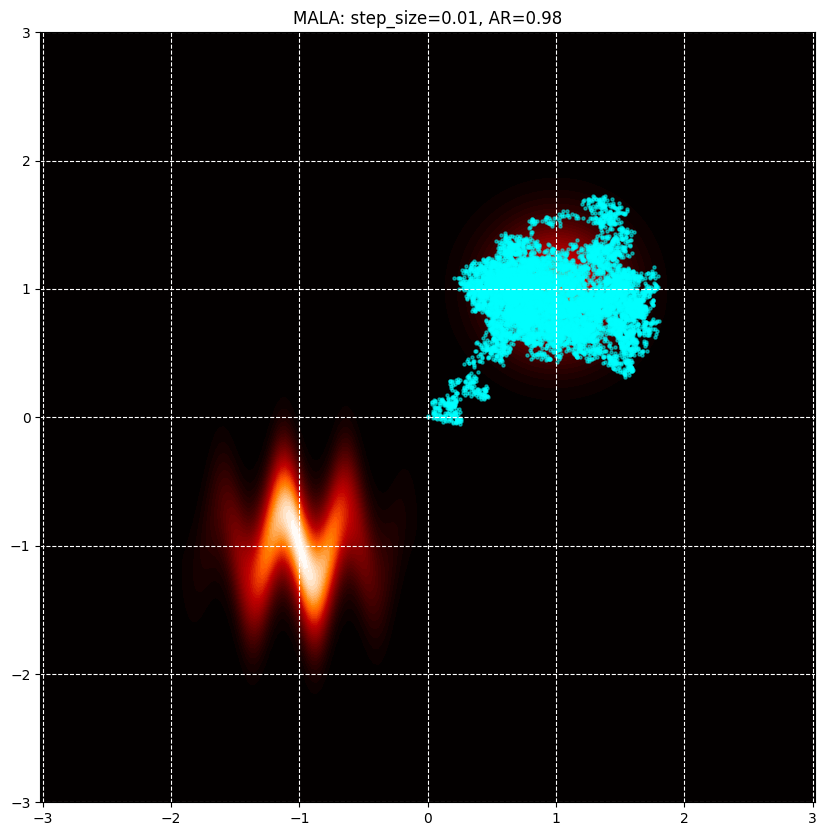

In [19]:
###############################################
# 3) Langevin Monte Carlo (MALA)
###############################################
# Update rule (MALA):
# y = x - (step_size/2)*grad(U(x)) + sqrt(step_size)*N(0,I)
# The probability of accepting the move from x to y is given by the M-H step
# with adjusted proposals taking the gradient into account.

def mala(U, grad_U, n_samples=10000, step_size=0.05, seed=42):
    torch.manual_seed(seed)
    samples = []
    accept_count = 0

    # Initialize from zero
    x_current = torch.zeros(1,2)
    f_current = torch.exp(-U(x_current))[0].item()

    for i in range(n_samples):
        grad = grad_U(x_current)

        # Proposed move (Langevin step):
        # Note: MALA is the Euler-Maruyama discretization of the Langevin diffusion
        y = x_current - 0.5 * step_size * grad + (step_size**0.5)*torch.randn(1,2)

        f_y = torch.exp(-U(y))[0].item()

        # Forward proposal q(y|x): Normal with mean (x - step_size/2 * grad_U(x)) and variance step_size*I
        # Backward proposal q(x|y): Similarly defined but with grad at y
        def log_q(z, mean):
            diff = z - mean
            return -0.5*(1.0/step_size)*torch.sum(diff**2)

        mean_forward = x_current - 0.5*step_size*grad
        log_q_forward = log_q(y, mean_forward)

        grad_y = grad_U(y)
        mean_backward = y - 0.5*step_size*grad_y
        log_q_backward = log_q(x_current, mean_backward)

        # MALA acceptance probability
        # alpha = min(1, f(y)*q(x|y) / [f(x)*q(y|x)])
        # in log form:
        # log_alpha = (log f(y) - log f(x)) + (log_q(x|y) - log_q(y|x))
        log_alpha = (np.log(f_y + 1e-16) - np.log(f_current + 1e-16)) \
                    + (log_q_backward.item() - log_q_forward.item())
        alpha = np.exp(log_alpha)

        # Accept/Reject step
        if np.random.rand() <= alpha:
            x_current = y
            f_current = f_y
            accept_count += 1
            # Store the current sample (whether accepted move or not, we store the chain)
            samples.append(x_current.numpy().flatten())

    samples = np.array(samples)
    acceptance_rate = accept_count / n_samples
    print("Number of accepted samples:", accept_count)
    return samples, acceptance_rate

# Run MALA with chosen step_size
samples, ar = mala(U, grad_U, n_samples=10000, step_size=0.0005)
print(f"MALA: step_size=0.05, acceptance_rate={ar:.3f}")

plt.figure(figsize=(10,10))
ax = plt.axes()
ax.set_facecolor("black")
plt.contourf(xx, yy, dens, levels=50, cmap="gist_heat")
plt.scatter(samples[:,0], samples[:,1], c='cyan', s=5, alpha=0.5)
plt.grid(color='white', linestyle='--')
plt.title(f"MALA: step_size=0.01, AR={ar:.2f}")
plt.axis('equal')
plt.show()

** Programming Assisted By Github Copilot and ChatGPT